In [38]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [39]:
data = pd.read_csv("E:\ANN_projects\Churn_Modelling.csv")

In [40]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: >

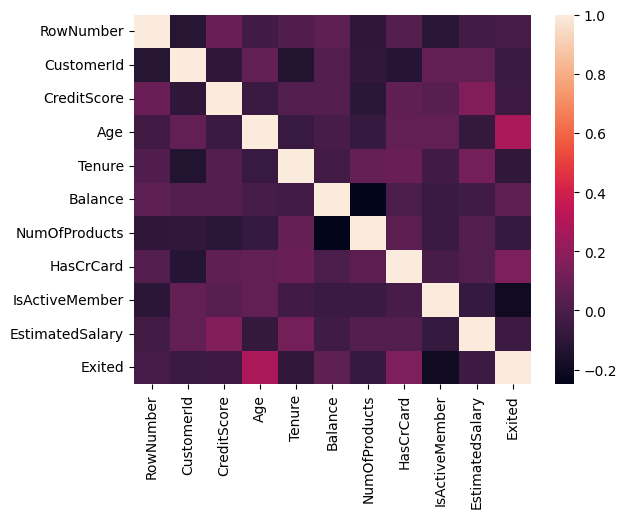

In [41]:
cors = data.select_dtypes(include=['number']).corr()
sns.heatmap(cors)

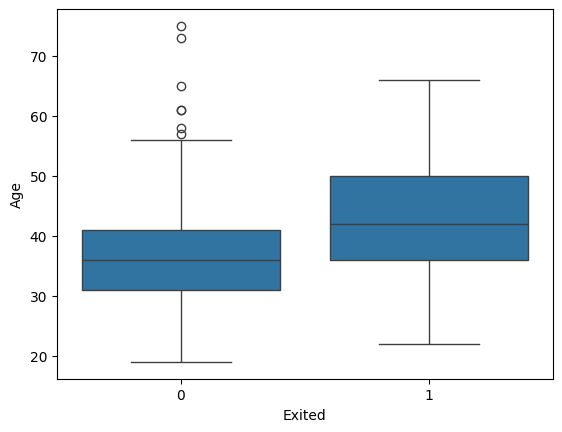

In [42]:
sns.boxplot(x='Exited',y='Age',data= data)
plt.show()

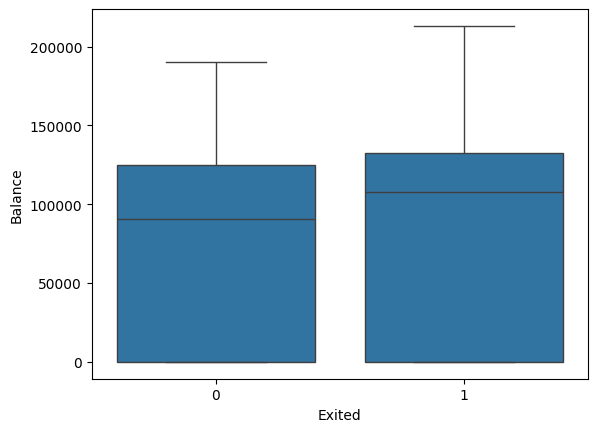

In [43]:
sns.boxplot(x='Exited',y='Balance',data=data)
plt.show()

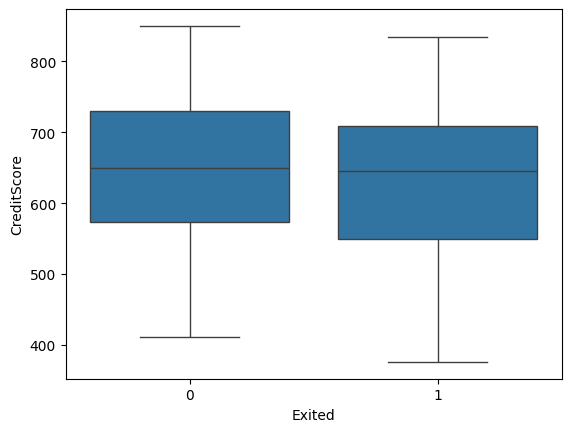

In [44]:
sns.boxplot(x='Exited',y='CreditScore',data=data)
plt.show()

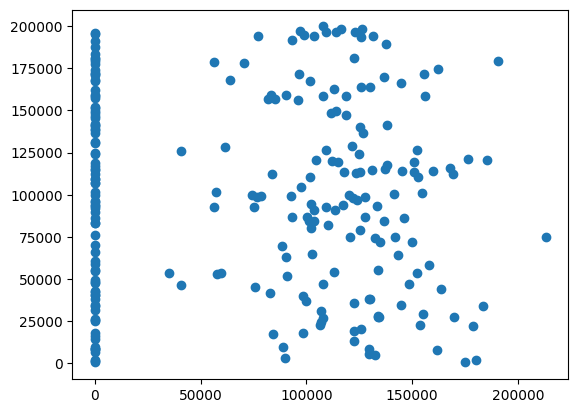

In [45]:
plt.scatter(data['Balance'] ,data['EstimatedSalary'])

In [46]:
data['Gender'].value_counts()

Gender
Male      128
Female    112
Name: count, dtype: int64

In [47]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data['encoded'] = encoder.fit_transform(data['Gender'])
data[['Exited','encoded']].head()

,Exited,encoded
0,1,0
1,0,0
2,1,0
3,0,0
4,0,0


In [48]:
data['encoded'].value_counts()

encoded
1    128
0    112
Name: count, dtype: int64

In [49]:
m_value =  128
f_value = 112
m_churn,f_churn =0,0
for i in range(0,len(data)):
    if(data['Exited'][i]==1 and data['encoded'][i]==1):
        m_churn+=1
    
    elif(data['Exited'][i]==1 and data['encoded'][i]==0):
        f_churn+=1

In [50]:
x=[m_churn,f_churn]
print(x)

[18, 31]


<BarContainer object of 2 artists>

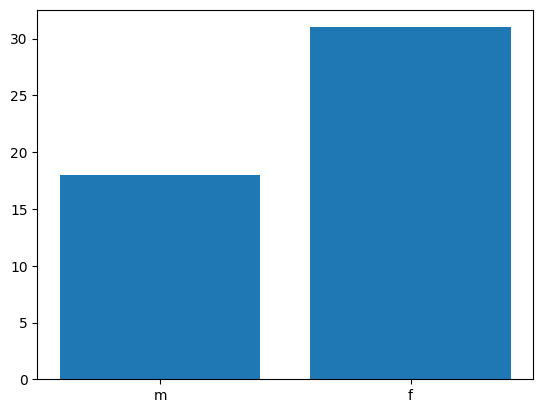

In [51]:
plt.bar(['m','f'],[m_churn,f_churn])

In [52]:
y= data['Exited']
x= data[["CreditScore","encoded",	"Age" ,"Tenure","Balance","EstimatedSalary"]] 

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_tr , x_ts , y_tr , y_ts = train_test_split(x, y, test_size=0.2)

scaling = StandardScaler()

scaling.fit(x_tr)

x_tr = scaling.transform(x_tr)
x_ts = scaling.transform(x_ts)

In [56]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_tr,y_tr)
model.score(x_tr,y_tr)

0.8177083333333334

In [57]:
model.coef_

array([[-0.21272117, -0.23841804,  0.50518484, -0.21751334,  0.31230839,
        -0.15139349]])

In [ ]:
from sklearn.pipeline import make_pipeline
test_score =[]
for lam in np.arange(0.01,100,0.1):
    pipe = make_pipeline(StandardScaler() , LogisticRegression(C= 1/lam))
    pipe.fit(x_tr,y_tr)
    scores = pipe.score(x_tr,y_tr)
    test_score.append(scores)

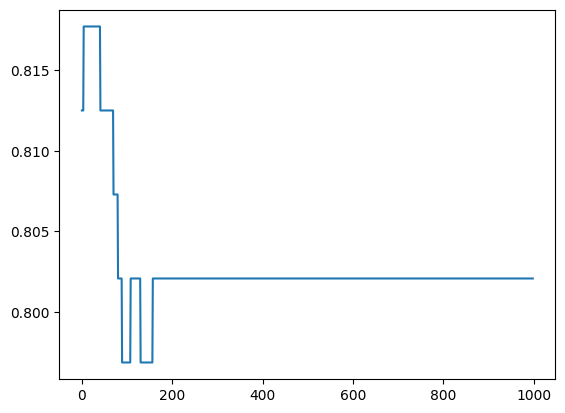

In [63]:
plt.plot(test_score)

In [65]:
print(test_score)
np.argmax(test_score)


[0.8125, 0.8125, 0.8125, 0.8125, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8177083333333334, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8

np.int64(4)

In [66]:
lam_best = 0.01*4*0.1
print(lam_best)

0.004
